In [26]:
import os
import pandas as pd
pd.options.mode.string_storage = "python"
pd.options.future.infer_string = False

import pickle
import numpy as np
import matplotlib.pyplot as plt
import pyreadr
import math

In [27]:
def read_in(data_folder, admin, max_lag,
            start_year=2015, start_month=1, end_year=2024, end_month=12,
            standardise=True, celsius=True, tp_log=True, dropna=True,
            select_admin1_regions=None, select_admin2_regions=None):
    valid_admin2 = pd.read_csv(os.path.join(data_folder, 'valid_admin/valid_admin2.csv'), header=None)[0].tolist()
    valid_admin1 = pd.read_csv(os.path.join(data_folder, 'valid_admin/valid_admin1.csv'), header=None)[0].tolist()
    valid_admin2.sort()
    valid_admin1.sort()
    va = {1: valid_admin1, 2: valid_admin2}

    # admin_year (urb, surv, urb_surv)
    admin_year_urbanisation = pd.read_csv(os.path.join(data_folder, f'admin_year_urbanisation/admin{admin}_year_urbanisation.csv'))

    admin_year_surveillance = pd.read_csv(os.path.join(data_folder, f'admin_year_surveillance/admin{admin}_year_surveillance.csv'))
    admin_year_urban_surveillance = pd.read_csv(os.path.join(data_folder, f'admin_year_urban_surveillance/admin{admin}_year_urban_surveillance.csv'))
    admin_year_density = pd.read_csv(os.path.join(data_folder, f'admin_year_density/admin{admin}_year_density.csv'))
    admin_year_pop = pd.read_csv(os.path.join(data_folder, f'admin_year_pop/admin{admin}_year_pop.csv'))

    admin_year = pd.merge(pd.merge(pd.merge(pd.merge(admin_year_urbanisation, admin_year_surveillance, on=[f'admin{admin}', 'year']),
                                   admin_year_urban_surveillance, on=[f'admin{admin}', 'year']),
                                   admin_year_pop, on=[f'admin{admin}', 'year']),
                                   admin_year_density, on=[f'admin{admin}', 'year'])
    new_cols = admin_year.columns.tolist()
    new_cols.remove('population')
    new_cols.insert(2, 'population')
    admin_year = admin_year.reindex(columns=new_cols)

    # admin_year_month (cases + ONI) + weather_stats(lag))

    # admin_year_month
    admin2_year_month_cases  = pyreadr.read_r(os.path.join(data_folder, 'cases_deaths_pop_2016_2024_38.rds'))[None]
    admin2_year_month_cases = admin2_year_month_cases.loc[:, ['admin1', 'admin2', 'year', 'month', 'cases']]
    admin2_year_month_cases = admin2_year_month_cases.astype({'year': 'int32', 'month': 'int32'})
    admin_year_month_cases = (admin2_year_month_cases[admin2_year_month_cases[f"admin{admin}"].isin(va[admin])].sort_values([f"admin{admin}", 'year', 'month']).reset_index(drop=True))
    if admin==1:
        admin_year_month_cases = admin2_year_month_cases[['admin1', 'year', 'month', 'cases']].groupby(['admin1', 'year', 'month'], as_index=False).agg(lambda x: x.sum() if not x.isna().any() else np.nan)
        # size = admin2_year_month_cases[['admin1', 'year', 'month', 'cases']].groupby(['admin1', 'year', 'month'], as_index=False).size()
        # count = admin2_year_month_cases[['admin1', 'year', 'month', 'cases']].groupby(['admin1', 'year', 'month'], as_index=False).count()
    elif admin==2:
        admin_year_month_cases = admin2_year_month_cases
    else:
        raise ValueError("admin must be 1 or 2")
    
    # ONI
    ONI = pd.read_csv(os.path.join(data_folder, 'ONI/ONI.csv'))
    ONI = ONI.loc[(ONI['year'] >= 2016) & (ONI['year'] <= 2024), ['year', 'month', 'ONI']].reset_index(drop=True)

    admin_year_month = admin_year_month_cases.merge(ONI, on=['year', 'month'], how='left')

    # Climate statistics
    admin_year_month_climate_statistics = pd.read_csv(os.path.join(data_folder,
                                                                   f'admin_year_month_climate_statistics/admin{admin}_year_month_climate_statistics.csv'))
    admin_year_month_tp_statistics = pd.read_csv(os.path.join(data_folder,
                                                                   f'admin_year_month_tp_statistics/admin{admin}_year_month_tp_statistics_fix.csv'))
    
    admin_year_month_climate_statistics = admin_year_month_climate_statistics.merge(admin_year_month_tp_statistics, on=[f'admin{admin}', 'year', 'month'], how='left')
    admin_year_month_climate_statistics = admin_year_month_climate_statistics.drop(columns=['tp_mean_unweighted', 'tp_mean_pop_weighted'], inplace=False)
    if celsius:
        t2m_cols = [col for col in admin_year_month_climate_statistics.columns if col.startswith("t2m")]
        admin_year_month_climate_statistics[t2m_cols] = admin_year_month_climate_statistics[t2m_cols] - 273.15
    if tp_log:
        tp_cols = [col for col in admin_year_month_climate_statistics.columns if col.startswith("tp")]
        for c in tp_cols:
            admin_year_month_climate_statistics[c + '_log1p'] = np.log1p(admin_year_month_climate_statistics[c])
            admin_year_month_climate_statistics[c + '_log'] = np.log(admin_year_month_climate_statistics[c]+1e-6)
    
    for lag in range(0, max_lag + 1):
        admin_year_month_climate_statistics_lag = admin_year_month_climate_statistics.copy()
        new_cols = admin_year_month_climate_statistics_lag.columns[0:3].to_list() + [c+f'({lag})' for c in admin_year_month_climate_statistics_lag.columns[3:]]
        admin_year_month_climate_statistics_lag.rename(columns={admin_year_month_climate_statistics_lag.columns[i]: new_cols[i] for i in range(len(new_cols))}, inplace=True)
        admin_year_month_climate_statistics_lag['month'] += lag
        admin_year_month_climate_statistics_lag.loc[admin_year_month_climate_statistics_lag['month'] > 12, 'year'] += 1
        admin_year_month_climate_statistics_lag.loc[admin_year_month_climate_statistics_lag['month'] > 12, 'month'] -= 12
        if lag==0:
            admin_year_month_climate_statistics_all_lags = admin_year_month_climate_statistics_lag
        else:
            admin_year_month_climate_statistics_all_lags = admin_year_month_climate_statistics_all_lags.merge(admin_year_month_climate_statistics_lag, on=[f'admin{admin}', 'year', 'month'], how='left')

    admin_year_month = admin_year_month.merge(admin_year_month_climate_statistics_all_lags, on=[f'admin{admin}', 'year', 'month'], how='left')
    full = admin_year_month.merge(admin_year, on=[f'admin{admin}', 'year'], how='left')

    full['date'] = pd.to_datetime(dict(year=full['year'], month=full['month'], day=1))
    mask1 = full['date'] >= pd.Timestamp(year=start_year, month=start_month, day=1)
    mask2 = full['date'] <= pd.Timestamp(year=end_year, month=end_month, day=1)
    full = full[mask1*mask2]
    full = full.drop(columns=['date'], inplace=False)

    if select_admin1_regions is not None:
        full = full[full[f'admin1'].isin(select_admin1_regions)].reset_index(drop=True)
    if select_admin2_regions is not None:
        if admin==1:
            raise ValueError("admin must be 2 to select admin2 regions")
        full = full[full[f'admin2'].isin(select_admin2_regions)].reset_index(drop=True)

    if dropna:
        full = full.dropna()

    if standardise:
        cols = ["urbanisation_nonweighted", "urbanisation_pop_weighted", "ONI"]
        for c in cols:
            x = full[c].astype(float)
            mu = np.mean(x)
            sd = np.std(x)
            full[c + "_std"] = (x - mu) / sd
    full = full[full[f'admin{admin}'].isin(va[admin])].reset_index(drop=True)
    full = full.sort_values([f'admin{admin}', 'year', 'month']).reset_index(drop=True)
    full['date'] = pd.to_datetime(full['year'].astype(str) + '-' + full['month'].astype(str) + '-01')
    full['rate'] = full['cases'] / full['population']
    return full

In [28]:
folder = "../../../../../data/lucaratzinger_data/p_dengue/"
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)

In [29]:
'population' in list(_data.columns)

True

In [106]:
f = 'dengue_indo_yearly'
sigma = 0.5
data_pickle = {(f, sigma): {}}
for year in _data['year'].unique():
    np.random.seed(42)
    condition = (_data['year'] == year) & (_data['t2m_mean_pop_weighted(0)'] < 20.0)
    select = np.random.choice(np.arange(len(_data.loc[condition])), size=len(_data.loc[condition]), replace=False)
    data_pickle[(f, sigma)][int(year)] = (_data.loc[condition, 't2m_mean_pop_weighted(0)'].iloc[select].values, _data.loc[condition, 'rate'].iloc[select].values*1e6)

In [110]:
f = 'dengue_indo_yearly_nb'
sigma = 0.5
data_pickle = {(f, sigma): {}}
for year in _data['year'].unique():
    np.random.seed(42)
    condition = (_data['year'] == year) & (_data['t2m_mean_pop_weighted(0)'] < 25.0)
    select = np.random.choice(np.arange(len(_data.loc[condition])), size=len(_data.loc[condition]), replace=False)
    data_pickle[(f, sigma)][int(year)] = (_data.loc[condition, 't2m_mean_pop_weighted(0)'].iloc[select].values, _data.loc[condition, 'cases'].iloc[select].astype(int).values)

In [134]:
f = 'dengue_indo_yearly_popnb'
sigma = 0.5
data_pickle = {(f, sigma): {}}
for year in _data['year'].unique():
    np.random.seed(42)
    condition = (_data['year'] == year) & (_data['t2m_mean_pop_weighted(0)'] < 30.0)
    select = np.random.choice(np.arange(len(_data.loc[condition])), size=len(_data.loc[condition]), replace=False)
    data_pickle[(f, sigma)][int(year)] = (_data.loc[condition, 't2m_mean_pop_weighted(0)'].iloc[select].values, (_data.loc[condition, 'cases'].iloc[select].astype(int).values, _data.loc[condition, 'population'].iloc[select].values))

In [ ]:
f = 'dengue_indo_yearly_popnb_1'
sigma = 0.5
data_pickle = {(f, sigma): {}}
r = 0
for year in _data['year'].unique():
    for variable in ['t2m_mean_pop_weighted', 't2m_max_pop_weighted', 't2m_min_pop_weighted', 'rh_mean_pop_weighted', 'tp_24hmean_pop_weighted_log', 'tp_24hmax_pop_weighted_log']:
        for lag in range(0, 7):
            v = f"{variable}({lag})"
            np.random.seed(42)
            condition = (_data['year'] == year) & # (_data[v] < 30.0)
            select = np.random.choice(np.arange(len(_data.loc[condition])), size=len(_data.loc[condition]), replace=False)
            data_pickle[(f, sigma)][int(r)] = (_data.loc[condition, v].iloc[select].values, (_data.loc[condition, 'cases'].iloc[select].astype(int).values, _data.loc[condition, 'population'].iloc[select].values))
            r += 1

In [37]:
f = 'dengue_indo_yearly_popnb_2'
sigma = 0.5
data_pickle = {}
r = 0

for variable in ['t2m_mean_pop_weighted', 't2m_max_pop_weighted', 't2m_min_pop_weighted', 'rh_mean_pop_weighted', 'tp_24hmean_pop_weighted_log', 'tp_24hmax_pop_weighted_log']:
    r = 0
    data_pickle[(variable, sigma)] = {}
    for lag in range(0, 7):
        v = f"{variable}({lag})"
        for year in _data['year'].unique():
            np.random.seed(42)
            condition = (_data['year'] == year) #& (_data[v] < 30.0)
            select = np.random.choice(np.arange(len(_data.loc[condition])), size=len(_data.loc[condition]), replace=False)
            data_pickle[(variable, sigma)][int(r)] = (_data.loc[condition, v].iloc[select].values, (_data.loc[condition, 'cases'].iloc[select].astype(int).values, _data.loc[condition, 'population'].iloc[select].values))
            r += 1

In [38]:
len(data_pickle[(f, sigma)][0][0])

KeyError: ('dengue_indo_yearly_popnb_2', 0.5)

In [39]:
dengue_data_path = os.path.join("../data", f"{f}.pkl")
if True:
    with open(dengue_data_path, "wb") as f:
        pickle.dump(data_pickle, f)
with open(dengue_data_path, "rb") as f:
    data_dict = pickle.load(f)

In [98]:
_data.groupby('admin1').size()

admin1
ACEH                          1104
BALI                           432
BANTEN                         384
BENGKULU                       470
DAERAH ISTIMEWA YOGYAKARTA     240
DKI JAKARTA                    240
GORONTALO                      284
JAMBI                          528
JAWA BARAT                    1296
JAWA TENGAH                   1680
JAWA TIMUR                    1791
KALIMANTAN BARAT               644
KALIMANTAN SELATAN             624
KALIMANTAN TENGAH              668
KALIMANTAN TIMUR               480
KALIMANTAN UTARA               180
KEPULAUAN BANGKA BELITUNG      336
KEPULAUAN RIAU                 332
LAMPUNG                        705
MALUKU                         524
MALUKU UTARA                   480
NUSA TENGGARA BARAT            436
NUSA TENGGARA TIMUR           1054
PAPUA                          384
PAPUA BARAT                    336
PAPUA BARAT DAYA               288
PAPUA PEGUNUNGAN               288
PAPUA SELATAN                  180
PAPUA TENGAH 

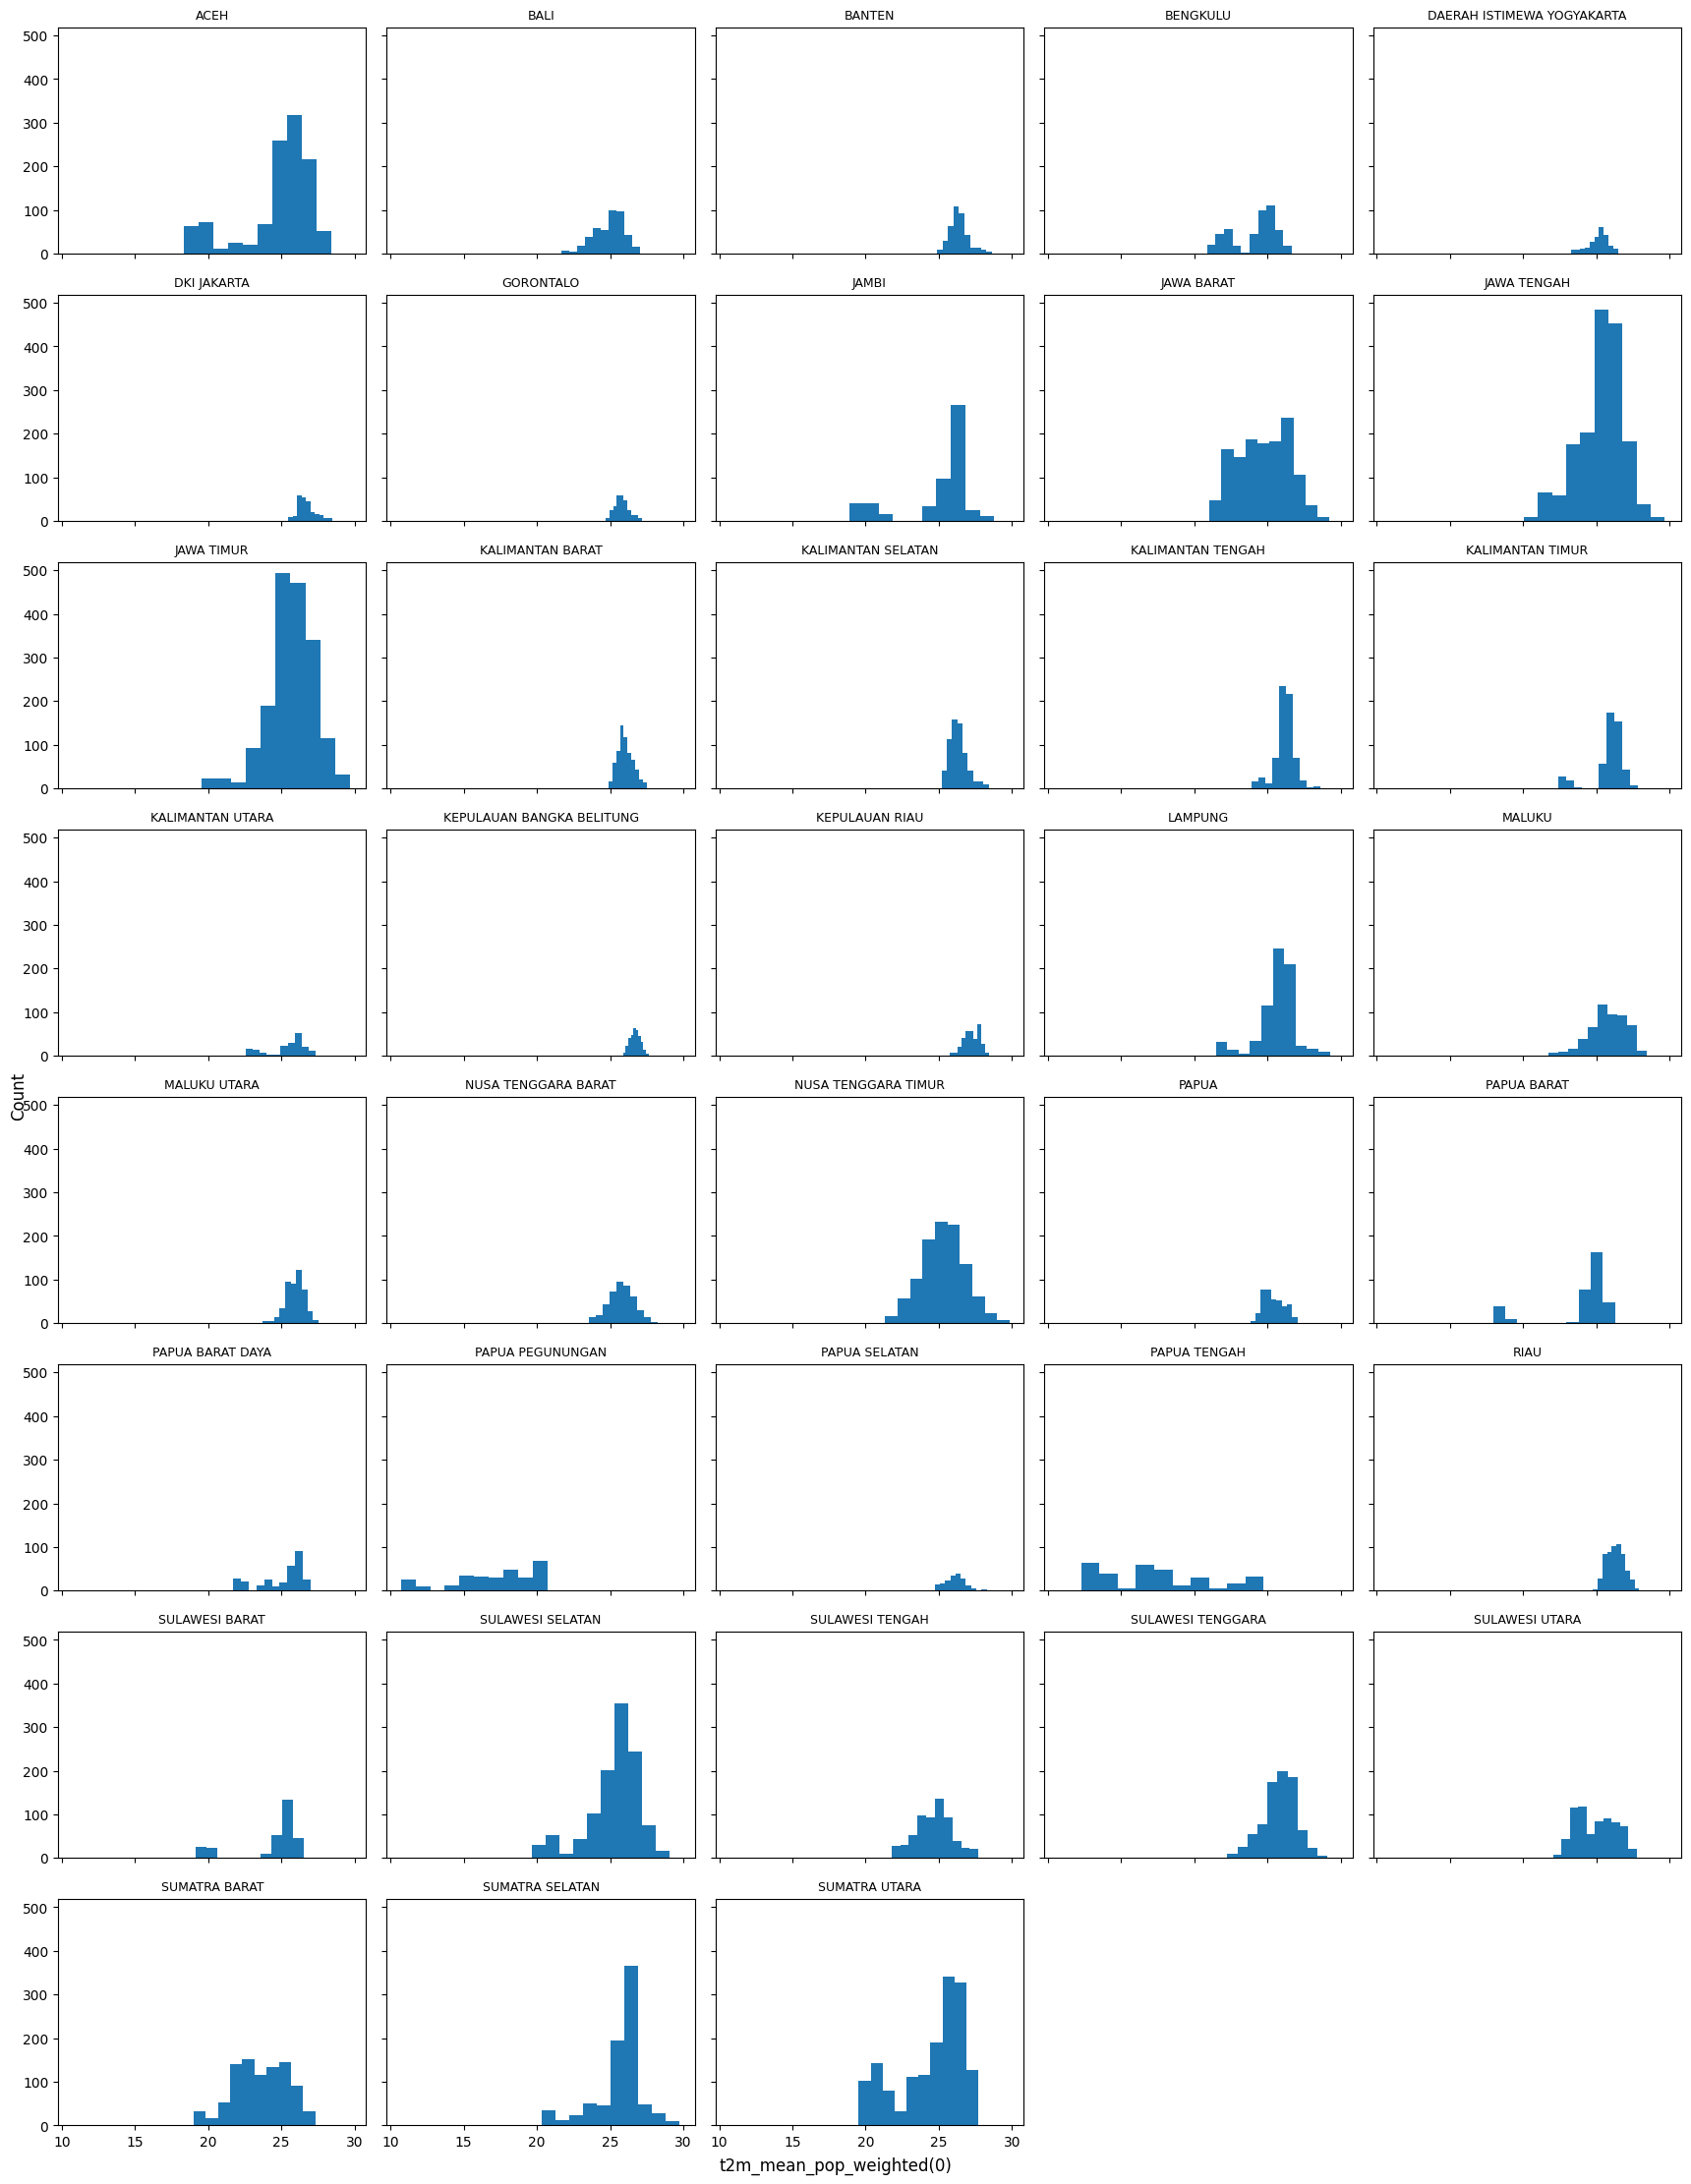

In [32]:
# ------------------------------------------------------------------
column = "t2m_mean_pop_weighted(0)"
bins = 10
# ------------------------------------------------------------------

groups = list(_data.groupby("admin1"))

n = len(groups)
ncols = 5
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.5 * ncols, 2.8 * nrows),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for ax, (admin1, group) in zip(axes, groups):
    ax.hist(group[column].dropna(), bins=bins)
    ax.set_title(admin1, fontsize=9)

# Remove unused axes
for ax in axes[n:]:
    fig.delaxes(ax)

fig.supxlabel(column)
fig.supylabel("Count")
plt.tight_layout()
plt.show()

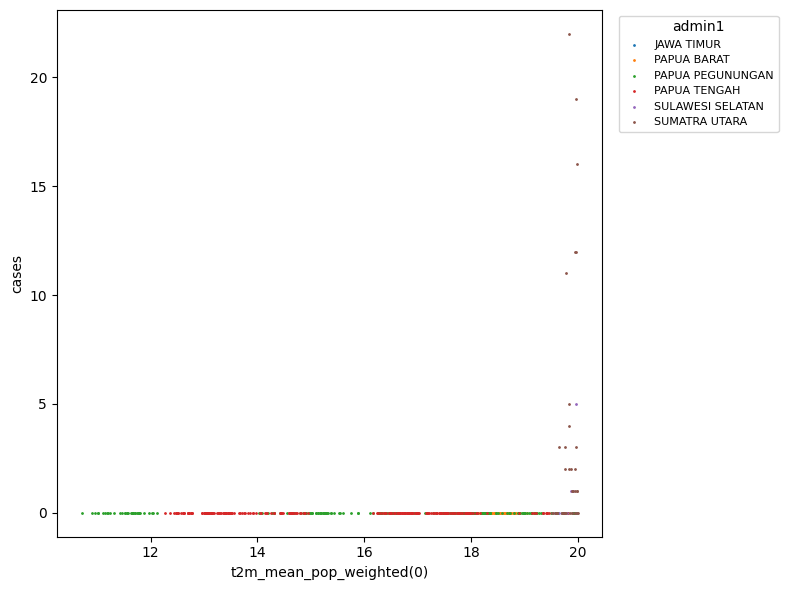

In [53]:
column = "t2m_mean_pop_weighted(0)"
regionList = ["ACEH", "SUMATRA BARAT", "JAMBI", "SULAWESI BARAT"]
mask = (_data[column] < 20) & ~(_data['admin1'].isin(regionList))

fig, ax = plt.subplots(figsize=(8, 6))

for admin1, group in _data.loc[mask].groupby("admin1"):
    ax.scatter(
        group[column],
        group["cases"],
        s=1,
        label=admin1
    )

ax.set_xlabel(column)
ax.set_ylabel("cases")
ax.legend(title="admin1", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

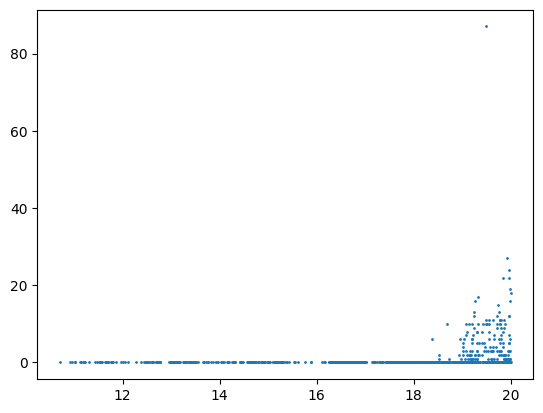

In [44]:
plt.scatter(_data.loc[_data['t2m_mean_pop_weighted(0)']<20, 't2m_mean_pop_weighted(0)'], _data.loc[_data['t2m_mean_pop_weighted(0)']<20, 'cases'], s=1)
plt.show()

In [38]:
(_data['t2m_mean_pop_weighted(0)']<20).sum()

np.int64(774)

In [23]:
data = _data.iloc[_data['admin2']=='ACEH BARAT']

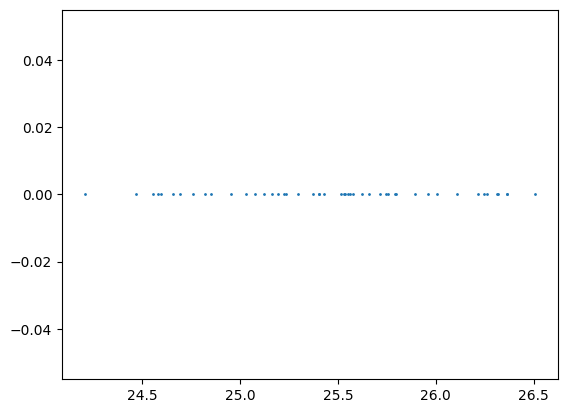

In [24]:
plt.scatter(data['t2m_mean_pop_weighted(0)'], y=np.zeros_like(data['t2m_mean_pop_weighted(0)']), s=1)
plt.show()